# Polymer dynamics with varying temperature and forces

First run the example to train and save the trained model
```shell
cd ./examples/polymer_dynamics
python polymer_dynamics_temperature.py --config-name polymer_dynamics_temperature_Fs.yaml
```

The results will be saved to a path in `./outputs/...` that appropriately time-stamped.

The rest of the notebook will perform analysis on the outputs.

In [1]:
import os

# Check and remove LD_LIBRARY_PATH if present
if 'LD_LIBRARY_PATH' in os.environ:
    print(f"Found LD_LIBRARY_PATH: {os.environ['LD_LIBRARY_PATH']}")
    del os.environ['LD_LIBRARY_PATH']
    print("✅ Removed LD_LIBRARY_PATH")
else:
    print("✅ LD_LIBRARY_PATH not set (good)")


os.environ['JAX_PLATFORMS'] = ''
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
os.environ['HF_HOME'] = "/home/qianxiao/nfs/huggingface"

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import numpy as np
from tqdm.auto import tqdm

Found LD_LIBRARY_PATH: /usr/local/cuda/lib64:
✅ Removed LD_LIBRARY_PATH


## Read saved model and config

In [2]:
from omegaconf import OmegaConf
from polymer_dynamics_wi import build_model
from datasets import load_dataset

In [3]:
# path = "outputs/2025_08_02-18_55_05"  # original data for PCA, scaled
# path = "outputs/2025_08_02-19_07_48"  # original data for PCA, unscaled
# path = "outputs/2025_08_04-18_12_13"  # full data for PCA, scaled
# path = "outputs/2025_08_04-18_32_55"  # full data for PCA, unscaled
# path = "outputs/2025_08_06-18_27_50"  # full data for PCA, unscaled, with aug  - to rerun

# path = "outputs/2025_08_12-12_20_01"  # original for PCA, unscaled, with aug
# path = "outputs/2025_08_12-23_03_19"  # full for PCA, unscaled, with aug


path = "outputs/2025_08_22-08_57_27"  # new Wi data (not uniform)
path = "outputs/2025_08_23-20_27_46"  # new Wi data (uniform) with 0.1 scaling to F
config = OmegaConf.load(os.path.join(path, ".hydra/config.yaml"))
model_template = build_model(config)
trained_model = eqx.tree_deserialise_leaves(os.path.join(path, "model.eqx"), model_template)

ERROR:2025-08-27 09:51:12,164:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/qianxiao/.cache/pypoetry/virtualenvs/onsagernet-evu6FzoF-py3.12/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/qianxiao/.cache/pypoetry/virtualenvs/onsagernet-evu6FzoF-py3.12/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/qianxiao/.cache/pypoetry/virtualenvs/onsagernet-evu6FzoF-py3.12/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.p

## Predictions

In [11]:
from datasets import load_from_disk

In [12]:
test_data_name = config.data.cache_path+"_test"
test_data = load_from_disk(test_data_name).with_format("numpy")
print(f"loaded: {test_data_name}")

loaded: pca_data_new_test


Analyse trajectory statistics

In [13]:
from examples.utils.sde import SDEIntegrator
integrator = SDEIntegrator(model=trained_model, state_dim=config.dim)

Helper functions

In [14]:
@jax.jit
def compute_unfolding_time(traj):
    unfolded_extension = traj[:, -1, 0]
    threshold = 0.95 * unfolded_extension
    first_index = jnp.argmin(traj[:, :, 0] <= threshold[:, None], axis=1)
    return first_index

In [15]:
dt = 0.0005 # TODO: Fix

In [16]:
def compare_statistics(test_data, test_split, key, return_results=False, args_override=None):

    # Extract data
    test_data_fast = test_data[f"{test_split}_fast"]
    test_data_medium = test_data[f"{test_split}_middle"]
    test_data_slow = test_data[f"{test_split}_slow"]

    # Convert to numpy arrays to support slice indexing
    test_x = [
        jnp.array(test_data_fast["x"]),
        jnp.array(test_data_medium["x"]),
        jnp.array(test_data_slow["x"])
    ]

    # Extract args correctly - they should be (2,) arrays
    test_args = [
        jnp.array(test_data_fast["args"])[0, 0],  # Extract the first args and ensure it's (2,)
        jnp.array(test_data_medium["args"])[0, 0],
        jnp.array(test_data_slow["args"])[0, 0]
    ]

    # Generate predicted trajectories
    keys = jr.split(key, 3)
    predicted_trajectories = []

    for i, (key, traj, args) in enumerate(zip(keys, test_x, test_args)):

        num_runs = traj.shape[0]
        traj_len = traj.shape[1]

        if args_override is not None:
            args = args_override

        init_conditions = jnp.repeat(traj[0, 0, :][None, :], num_runs, axis=0)
        bm_keys = jr.split(key, num_runs)

        # Use num_steps instead of t1 to avoid floating point precision issues
        num_steps = traj_len - 1  # Number of intervals (not points)

        sol = integrator.parallel_solve(
            key=bm_keys,
            initial_conditions=init_conditions,
            t0=0.0,
            t1=None,  # Will be computed as t0 + num_steps * dt
            dt=dt,
            args=args,
            num_steps=num_steps,  # This ensures exact length matching
        )

        predicted_trajectories.append(sol.ys)

    if return_results:
        return {"true_trajectories": test_x,
                "predicted_trajectories": predicted_trajectories,
                "args": test_args}

Compare statistics

In [17]:
def compare_all_statistics_combined(test_data, keys):
    """Create one large combined plot comparing all test splits and conditions"""

    test_splits = list(set(k.rsplit('_', 1)[0] for k in test_data.keys()))
    n_splits = len(test_splits)

    # Create a large figure with square aspect ratio: each subplot should be approximately square
    # 9 columns (3 conditions × 3 metrics), make height proportional to maintain square subplots
    subplot_size = 4  # Size of each subplot
    fig_width = 9 * subplot_size  # 9 columns
    fig_height = n_splits * subplot_size  # n_splits rows

    fig, axes = plt.subplots(n_splits, 9, figsize=(fig_width, fig_height), layout="constrained")

    # If only one split, make sure axes is 2D
    if n_splits == 1:
        axes = axes[None, :]

    # Collect all results first
    all_results = {}
    for i, (key, test_split) in enumerate(zip(keys, test_splits)):
        result = compare_statistics(test_data, test_split, key, return_results=True)
        all_results[test_split] = result

    # Now plot everything in the combined figure
    for i, test_split in enumerate(test_splits):
        result = all_results[test_split]
        true_trajs = result["true_trajectories"]
        pred_trajs = result["predicted_trajectories"]

        # For each condition (Fast, Medium, Slow)
        condition_names = ["Fast", "Medium", "Slow"]
        for j, (condition, true, pred) in enumerate(zip(condition_names, true_trajs, pred_trajs)):

            # Calculate statistics
            true_mean = jnp.mean(true, axis=0)
            pred_mean = jnp.mean(pred, axis=0)
            true_std = jnp.std(true, axis=0)
            pred_std = jnp.std(pred, axis=0)
            true_unfolding = compute_unfolding_time(true)
            pred_unfolding = compute_unfolding_time(pred)

            # Plot mean (column 0, 3, 6)
            col_idx = j * 3 + 0
            axes[i, col_idx].plot(true_mean[:, 0], label="True", alpha=0.8)
            axes[i, col_idx].plot(pred_mean[:, 0], label="Pred", alpha=0.8)
            axes[i, col_idx].set_title(f"{condition} - Mean")
            axes[i, col_idx].legend()
            axes[i, col_idx].grid(True, alpha=0.3)

            # Plot std (column 1, 4, 7)
            col_idx = j * 3 + 1
            axes[i, col_idx].plot(true_std[:, 0], label="True", alpha=0.8)
            axes[i, col_idx].plot(pred_std[:, 0], label="Pred", alpha=0.8)
            axes[i, col_idx].set_title(f"{condition} - Std Dev")
            axes[i, col_idx].legend()
            axes[i, col_idx].grid(True, alpha=0.3)

            # Plot unfolding time (column 2, 5, 8)
            col_idx = j * 3 + 2
            axes[i, col_idx].hist(true_unfolding, label="True", alpha=0.6, density=True, bins=15)
            axes[i, col_idx].hist(pred_unfolding, label="Pred", alpha=0.6, density=True, bins=15)
            axes[i, col_idx].set_title(f"{condition} - Unfolding Time")
            axes[i, col_idx].legend()
            axes[i, col_idx].grid(True, alpha=0.3)

        # Add row label (test split name)
        axes[i, 0].set_ylabel(f"{test_split}\nExtension", fontsize=12, fontweight='bold')

    # Add column labels at the top
    col_labels = ["Fast Mean", "Fast Std", "Fast Unfold",
                  "Medium Mean", "Medium Std", "Medium Unfold",
                  "Slow Mean", "Slow Std", "Slow Unfold"]
    for j, label in enumerate(col_labels):
        axes[0, j].set_title(label, fontsize=12, fontweight='bold')

    # Set x-labels only on bottom row
    for j in range(9):
        if j % 3 == 2:  # Unfolding time columns
            axes[-1, j].set_xlabel("Time Steps")
        else:  # Mean and std columns
            axes[-1, j].set_xlabel("Time")

    plt.suptitle("Combined Statistics Comparison Across All Conditions", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

    return all_results

Creating combined plot for 10 test splits...


/tmp/ipykernel_2423628/2646729734.py:85: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


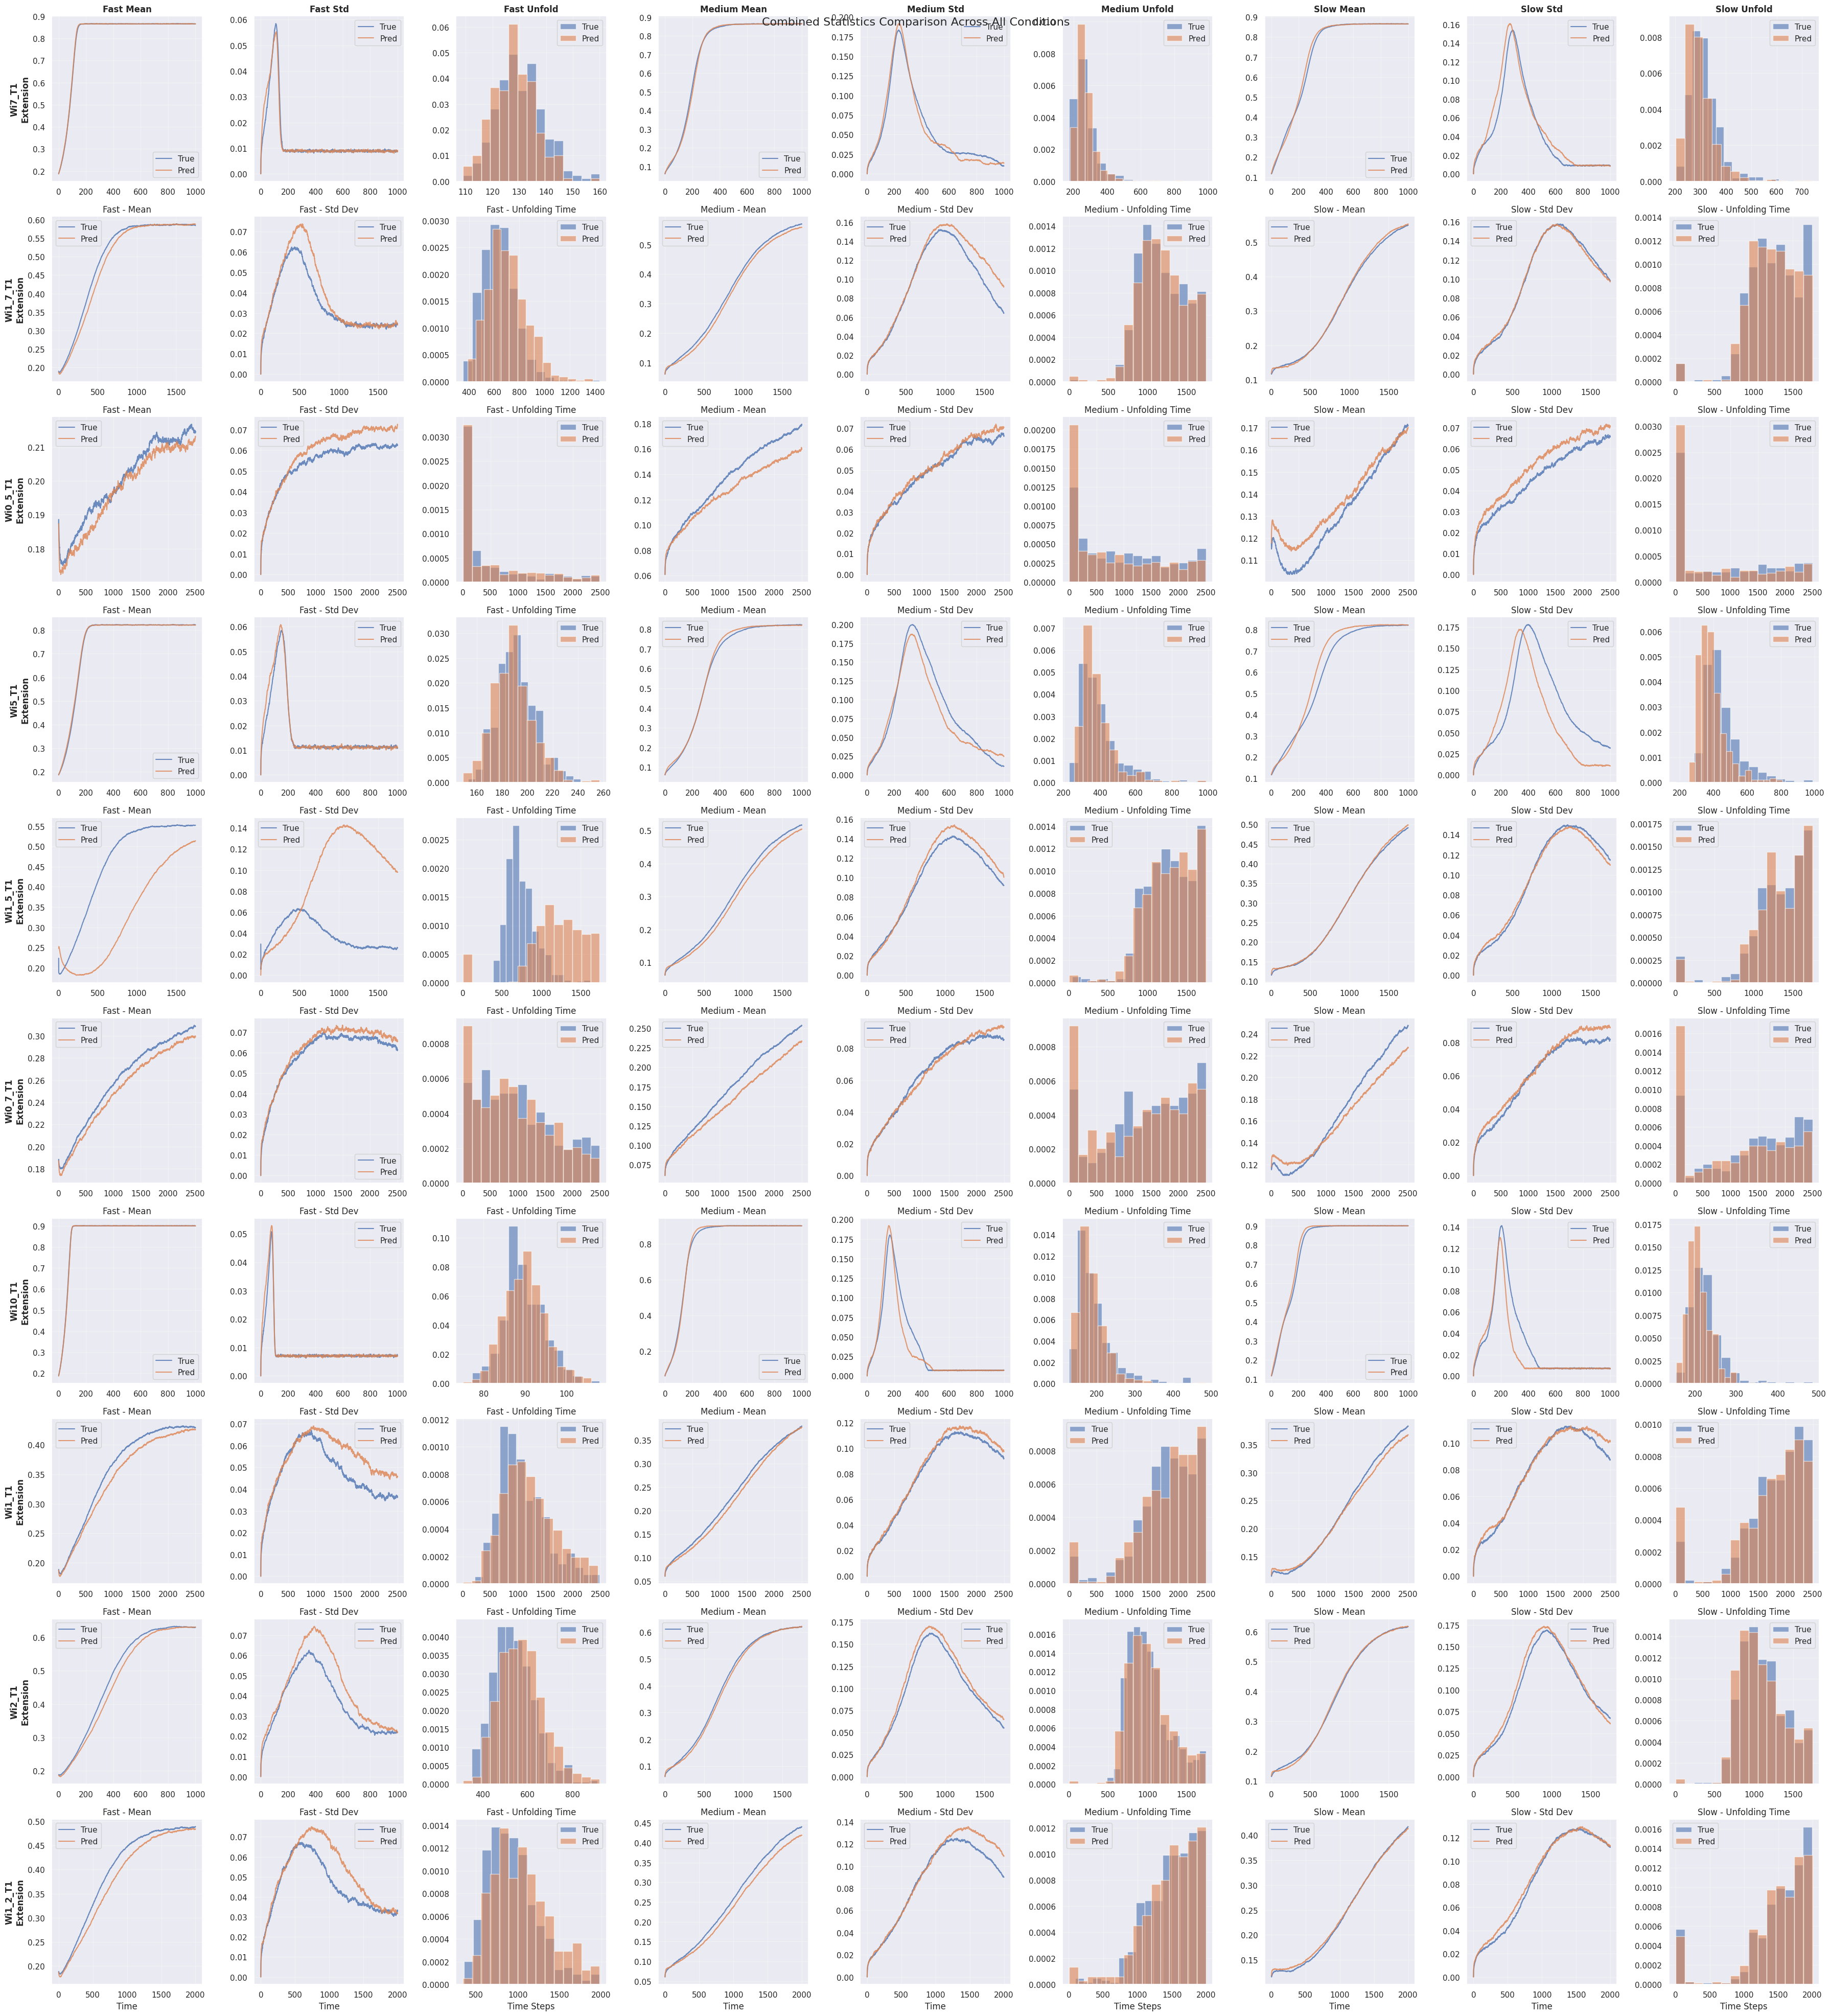

In [18]:
# Generate the combined plot
test_splits = set(k.rsplit('_', 1)[0] for k in test_data.keys())
keys = jr.split(jr.PRNGKey(config.model.seed + 123), len(test_splits))

print(f"Creating combined plot for {len(test_splits)} test splits...")
all_results = compare_all_statistics_combined(test_data, keys)